# Alberta infrastructure spending and delivery, 2015–16 to 2024–25

## tl;dr

Actual capital spending rose 19.6% from 2018–19 to 2024–25, but CPI-adjusted spending per resident fell 12.6%. The latest year improved 7.1% on the adjusted per-resident measure. Selected physical deliveries are documented; net provincial capacity and condition remain unquantified.

This notebook accompanies [REPORT.md](REPORT.md), which contains the physical evidence and exact source references. Evidence ends March 31, 2025, although the analysis date is October 9, 2026.

## Context & Methods

### Key assumptions

Capital Plan actuals are financial inputs, not physical capacity. All primary values use the 2024–25 report vintage, whose historical table warns of accounting changes. July 1 population and starting-calendar-year CPI approximate fiscal alignment. Chaining rounded CPI rates measures consumer purchasing power, not construction volume. UCP tenure begins during 2019–20; 2018–19 is the last full pre-UCP baseline.

The ten-year window is lagged: 2025–26 actuals are unavailable in the accessible corpus. No missing year or physical metric is imputed. There is no causal-policy model.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image
RUNTIME_EXECUTABLE = sys.executable
print('Python runtime:', RUNTIME_EXECUTABLE)
ROOT = Path.cwd()
assert (ROOT / 'scripts/analyze.py').exists(), 'Execute from Infrastructure Analysis'
sys.path.insert(0, str(ROOT / 'scripts'))
from analyze import load_primary, compare, period_summary, build_figures
DATA = load_primary()
COMPARISONS = pd.DataFrame([compare(DATA,y) for y in [2015,2018,2019,2022,2023]])
PERIODS = period_summary(DATA)
assert len(DATA) == 10 and DATA.fiscal_year.nunique() == 10
assert DATA.status.eq('actual').all()

Python runtime: /workspace/.venv-alberta-independent-check/bin/python


## Data

### 1. Inspect the actual-spending panel

Source: `Budget PDFs/2024-2025 Budget.pdf`, printed/PDF pages 13–14, June 2025 Final Results. CSV extracts preserve units, report vintage and exact page references. See `data/run_manifest.json` for source hashes. Population is in residents; original capital values are CAD millions.

In [2]:
display(DATA[['fiscal_year','capital_plan_actual_million','population_july_1','cpi_index_2015_100','capital_nominal_per_resident_cad','capital_cpi_adjusted_per_resident_2024_cad']].round(2))

,fiscal_year,capital_plan_actual_million,population_july_1,cpi_index_2015_100,capital_nominal_per_resident_cad,capital_cpi_adjusted_per_resident_2024_cad
0,2015-16,6558.0,4150000,100.00,1580.24,1996.66
1,2016-17,6578.0,4195000,101.10,1568.06,1959.71
2,2017-18,9021.0,4237000,102.72,2129.10,2618.98
3,2018-19,6057.0,4293000,105.18,1410.90,1694.86
4,2019-20,5545.0,4355000,107.08,1273.25,1502.46
5,2020-21,6896.0,4407000,108.25,1564.78,1826.38
6,2021-22,6622.0,4432000,111.72,1494.13,1689.84
7,2022-23,5633.0,4511000,118.87,1248.73,1327.34
8,2023-24,6300.0,4685000,122.79,1344.72,1383.71
9,2024-25,7243.0,4889000,126.35,1481.49,1481.49


### 2. Validate inputs and ratios

One-to-one joins prevent row multiplication. Independently reviewed demographic inputs must agree with the capital-source economic row. A compounded population × price benchmark is required; comparing each separately would understate their combined effect.

In [3]:
assert DATA.population_july_1.eq(DATA.population_july1_thousands*1000).all()
baseline = DATA.loc[DATA.calendar_year.eq(2018)].iloc[0]
endpoint = DATA.loc[DATA.calendar_year.eq(2024)].iloc[0]
ratio = (endpoint.capital_nominal_cad / baseline.capital_nominal_cad) / (endpoint.population_july_1 / baseline.population_july_1) / (endpoint.cpi_index_2015_100 / baseline.cpi_index_2015_100)
assert abs((ratio-1)*100 - COMPARISONS.loc[COMPARISONS.baseline.eq('2018-19'),'cpi_adjusted_per_resident_growth_pct'].iloc[0]) < 1e-9
print(f'2018–19 to 2024–25: CPI-adjusted spending per resident {(ratio-1)*100:+.4f}%')

2018–19 to 2024–25: CPI-adjusted spending per resident -12.5891%


## Results

### 3. Actual capital spending

The 2017–18 peak partly reflects grants accelerated from future years; annual spending is not construction delivered that year. The initial UCP-period decline follows an earlier fall. Source: final-results historical table, p. 14.

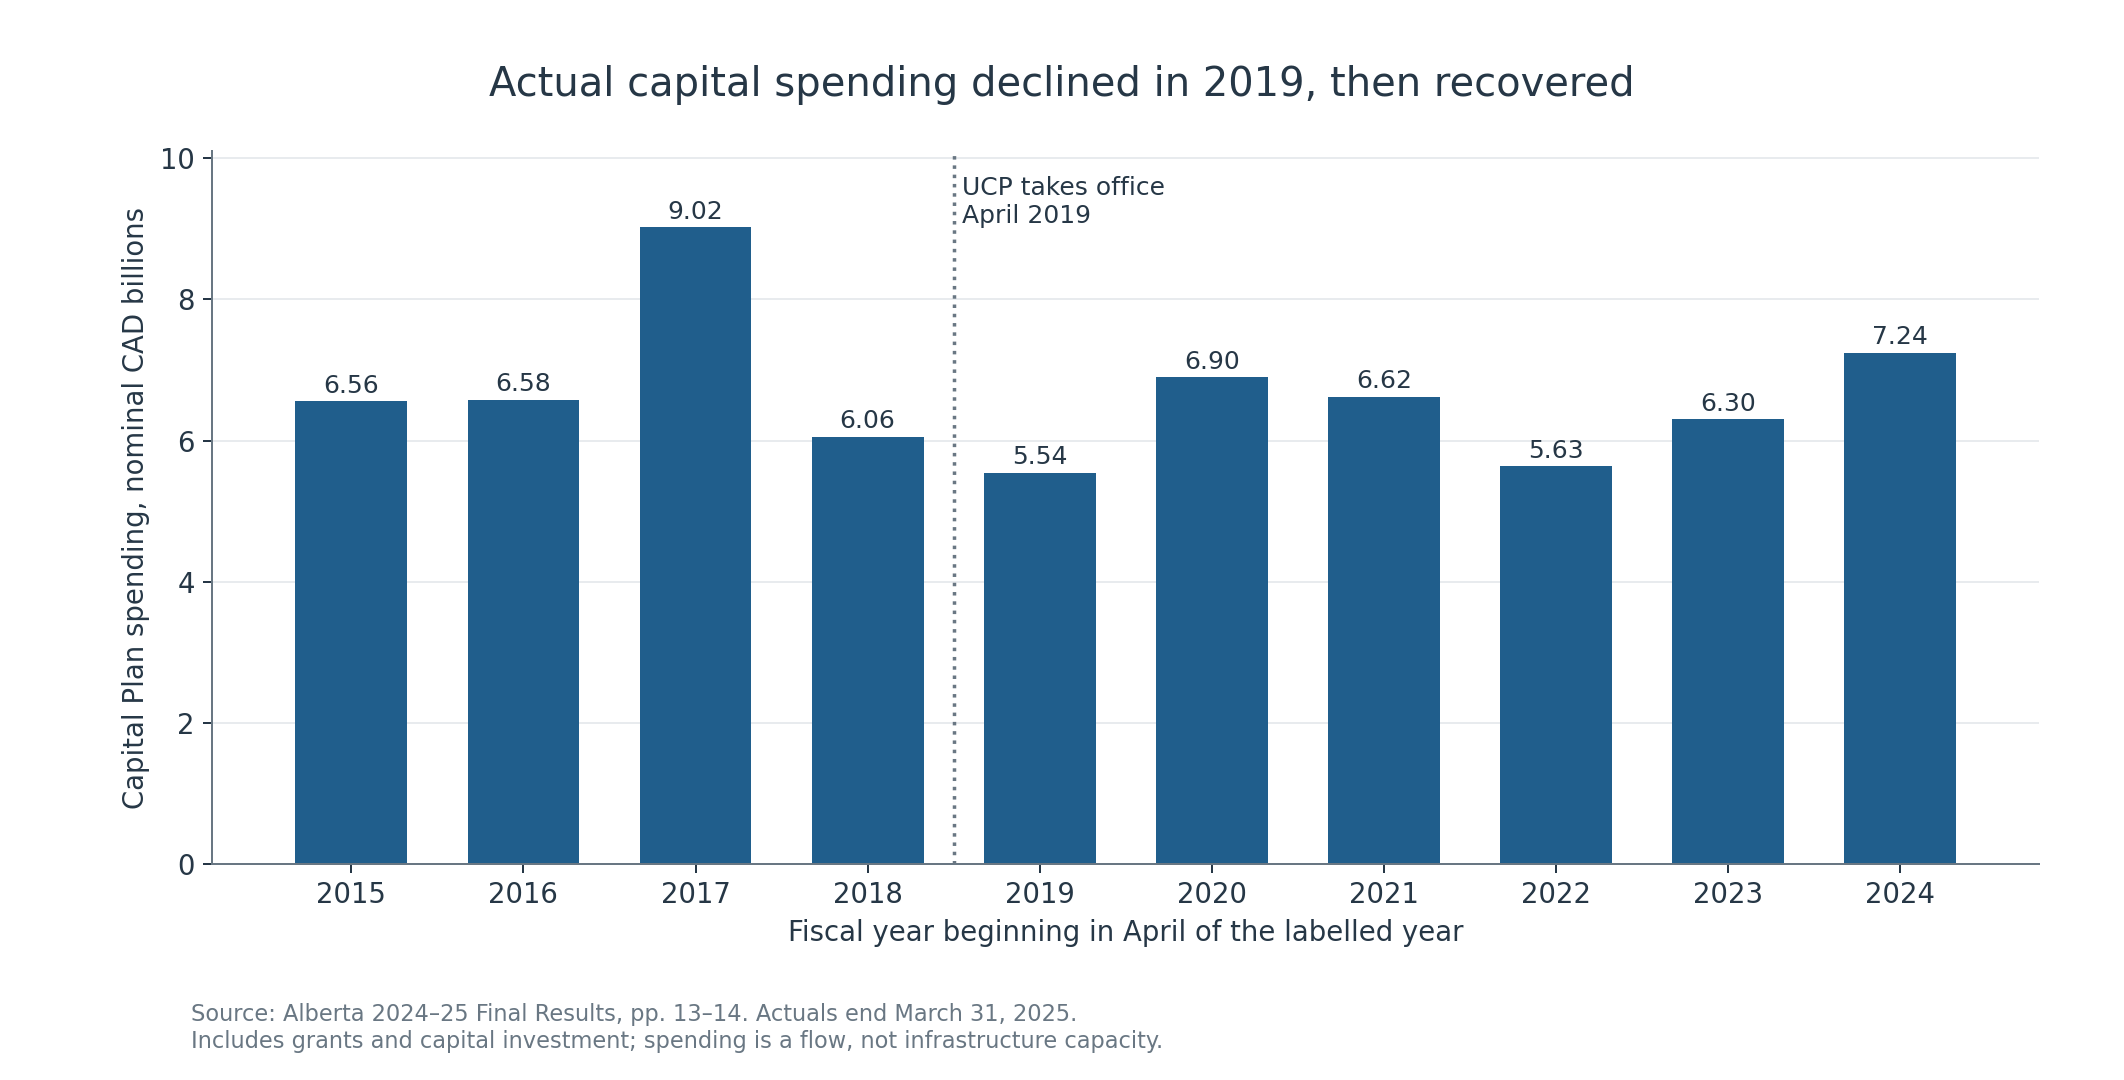

In [4]:
build_figures(DATA,COMPARISONS,PERIODS)
display(Image(filename=str(ROOT/'plots/01_actual_capital_spending.png'), alt='Actual capital spending by fiscal year: 6.558 billion in 2015–16, 9.021 billion peak in 2017–18, 5.545 billion in 2019–20, and 7.243 billion in 2024–25. The government transition occurs in April 2019.'))

### Reported budget execution and accounting composition

Each final-results report supplies paired budget and contemporary actual columns. These differ from the latest historical actual series when revised. Budget execution is not a project-delivery or efficiency score; the 2020–21 program was revised substantially with $1.1B COVID/recovery support. Never add yearly undershoots into an infrastructure backlog. Capital grants and consolidated investment also have different ownership/accounting implications.

Created paired contemporary budget-execution table and figure.


,fiscal_year,budget_million,contemporary_actual_million,budget_execution_pct,latest_2024_25_vintage_actual_million
0,2015-16,7863,6558,83.40,6558.0
1,2016-17,8481,6578,77.56,6578.0
2,2017-18,9175,9016,98.27,9021.0
3,2018-19,6444,6180,95.90,6057.0
4,2019-20,6206,5564,89.66,5545.0
5,2020-21,6960,6896,99.08,6896.0
6,2021-22,8114,6622,81.61,6622.0
7,2022-23,7534,5644,74.91,5633.0
8,2023-24,8005,6300,78.70,6300.0
9,2024-25,8299,7243,87.28,7243.0


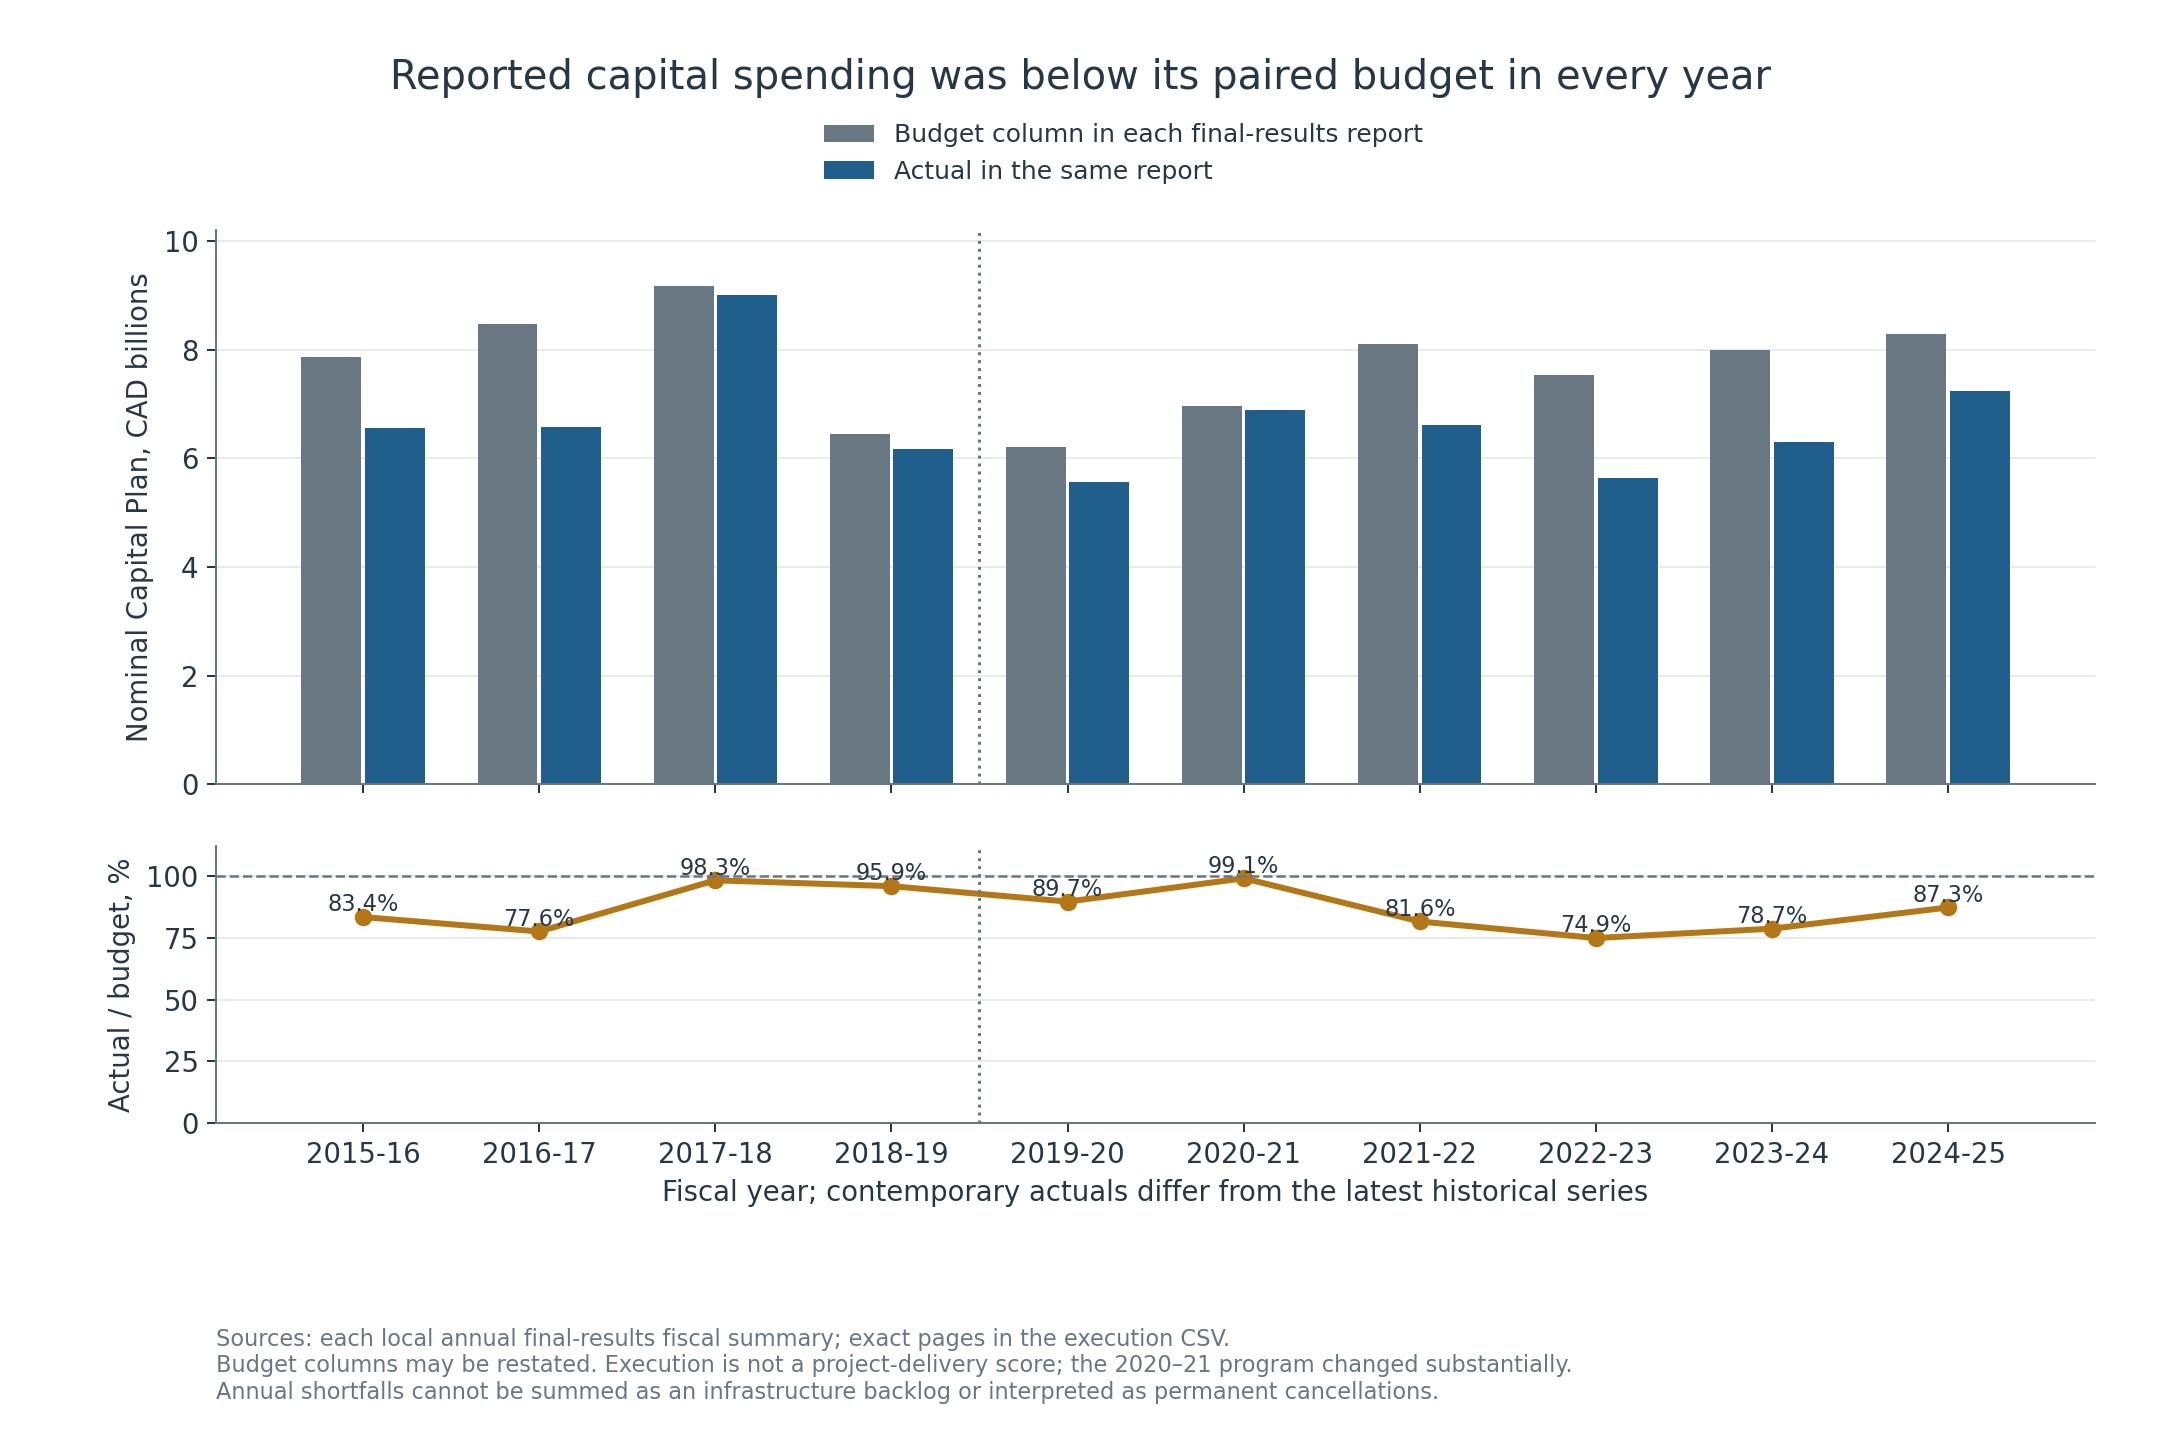

In [5]:
from execution_figures import build as build_execution_figure
EXECUTION = build_execution_figure()
display(EXECUTION[['fiscal_year','budget_million','contemporary_actual_million','budget_execution_pct','latest_2024_25_vintage_actual_million']].round(2))
display(Image(filename=str(ROOT/'plots/09_reported_budget_execution.png'), alt='Paired capital budget and contemporary actual spending from each final-results report. Spending was below the paired budget in all ten years; execution was 74.9 percent in 2022–23 and 87.3 percent in 2024–25. The 2020–21 ratio of 99.1 percent masks a materially revised program.'))

In [6]:
composition = pd.read_csv(ROOT/'research/capital/capital_composition_original_vintages.csv')
latest_composition = composition.loc[composition.source_vintage.eq('2024-25') & composition.column_status.isin(['actual','prior_actual'])]
display(latest_composition[['observation_fiscal_year','column_status','capital_grants_million','capital_investment_million','total_capital_plan_million']])
print('Latest increase: grants +$831M and investment +$112M = total +$943M; grants explain 88.1% of net nominal growth. Neither component measures net physical capacity.')

,observation_fiscal_year,column_status,capital_grants_million,capital_investment_million,total_capital_plan_million
28,2024-25,actual,2934,4309,7243
29,2023-24,prior_actual,2103,4197,6300


Latest increase: grants +$831M and investment +$112M = total +$943M; grants explain 88.1% of net nominal growth. Neither component measures net physical capacity.


### 4. Population-adjusted spending and the combined benchmark

The 2024–25 recovery remains below 2018–19 on a consumer-price-adjusted per-resident basis. This is not a measure of net school, hospital or road capacity.

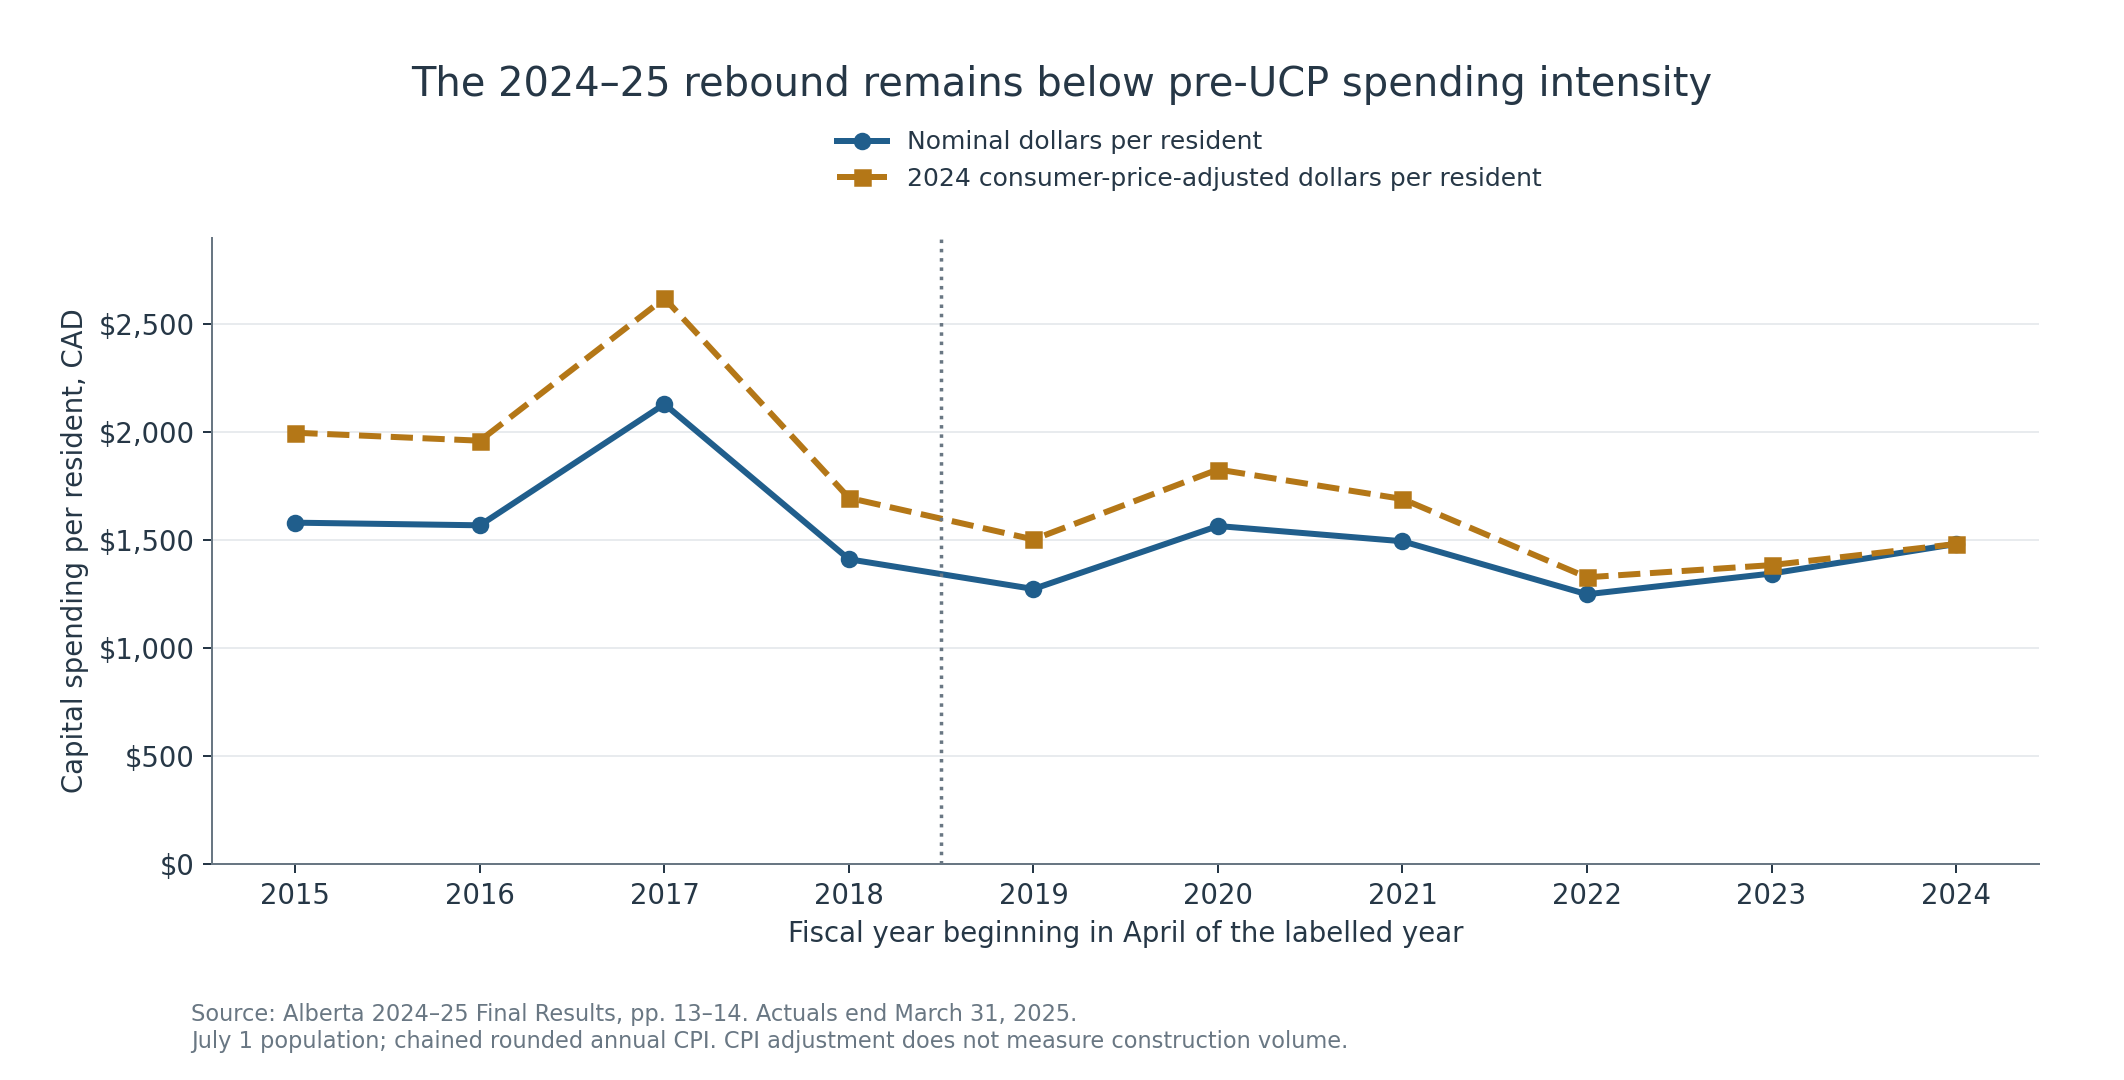

In [7]:
display(Image(filename=str(ROOT/'plots/02_spending_per_resident.png'), alt='Nominal and 2024 CPI-adjusted capital spending per resident, 2015–16 through 2024–25. CPI-adjusted spending falls from about 1695 dollars in 2018–19 to 1481 dollars in 2024–25.'))

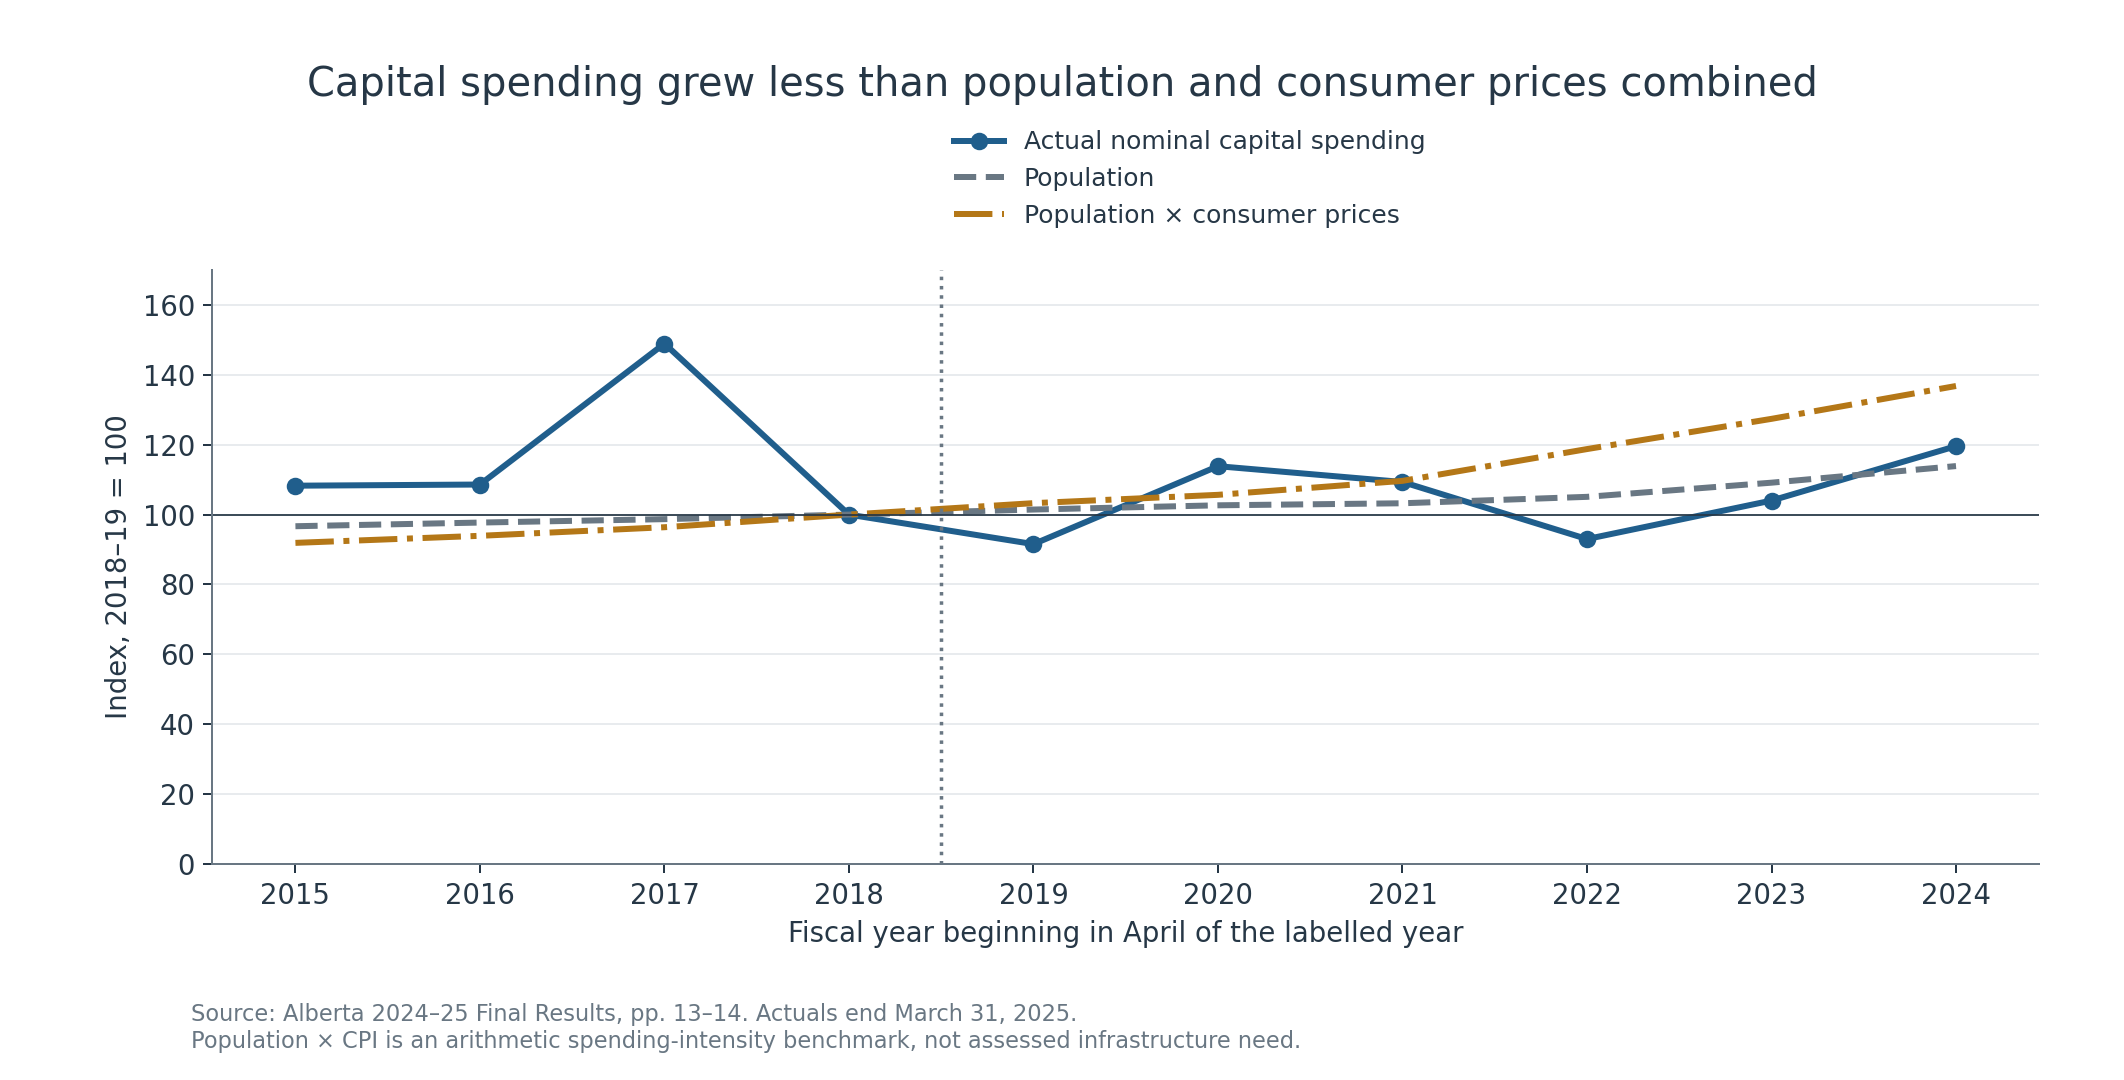

In [8]:
display(Image(filename=str(ROOT/'plots/03_growth_benchmarks.png'), alt='Indices with 2018–19 equal to 100. Capital spending reaches about 119.6, population 113.9, and population multiplied by consumer prices about 136.8 in 2024–25.'))

### 5. Baseline and period sensitivity

The first UCP year is already a lower baseline. Unequal tenure lengths require annual averages/intensity; this is descriptive and does not identify a causal government effect.

,baseline,endpoint,nominal_capital_growth_pct,population_growth_pct,cpi_growth_pct,cpi_adjusted_per_resident_growth_pct
0,2015-16,2024-25,10.45,17.81,26.35,-25.80
1,2018-19,2024-25,19.58,13.88,20.13,-12.59
2,2019-20,2024-25,30.62,12.26,18.00,-1.40
3,2022-23,2024-25,28.58,8.38,6.30,11.61
4,2023-24,2024-25,14.97,4.35,2.90,7.07


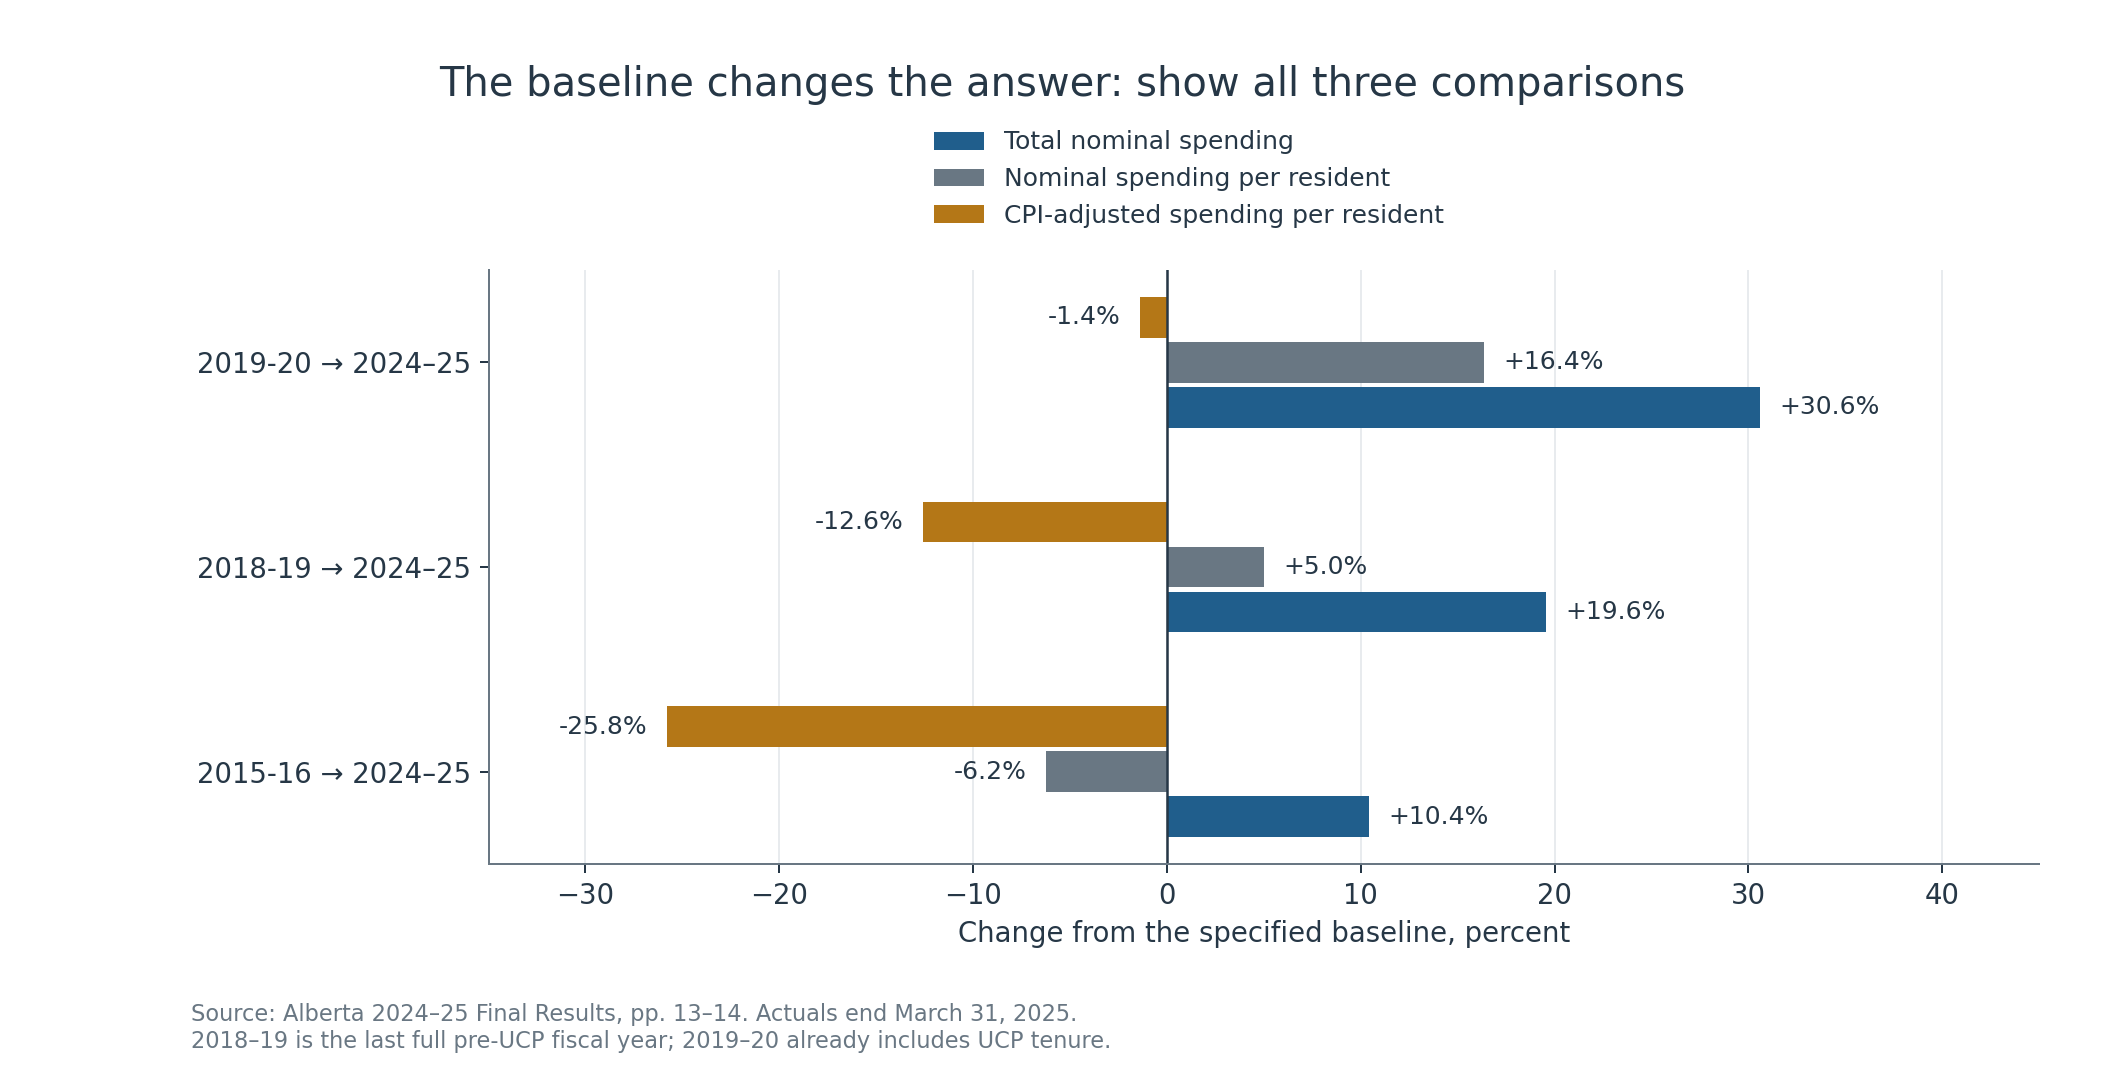

In [9]:
display(COMPARISONS[['baseline','endpoint','nominal_capital_growth_pct','population_growth_pct','cpi_growth_pct','cpi_adjusted_per_resident_growth_pct']].round(2))
display(Image(filename=str(ROOT/'plots/04_baseline_sensitivity.png'), alt='Three baseline comparisons to 2024–25. CPI-adjusted capital spending per resident changes by minus 25.8 percent from 2015–16, minus 12.6 percent from 2018–19, and minus 1.4 percent from 2019–20.'))

,period,fiscal_years,population_weighted_cpi_adjusted_per_resident_annual_2024_cad
0,2015-16 to 2018-19,4,2066.95
1,2019-20 to 2024-25,6,1532.12
2,2015-16 to 2018-19 excluding 2017-18 spike,3,1881.87
3,2022-23 to 2024-25,3,1399.60


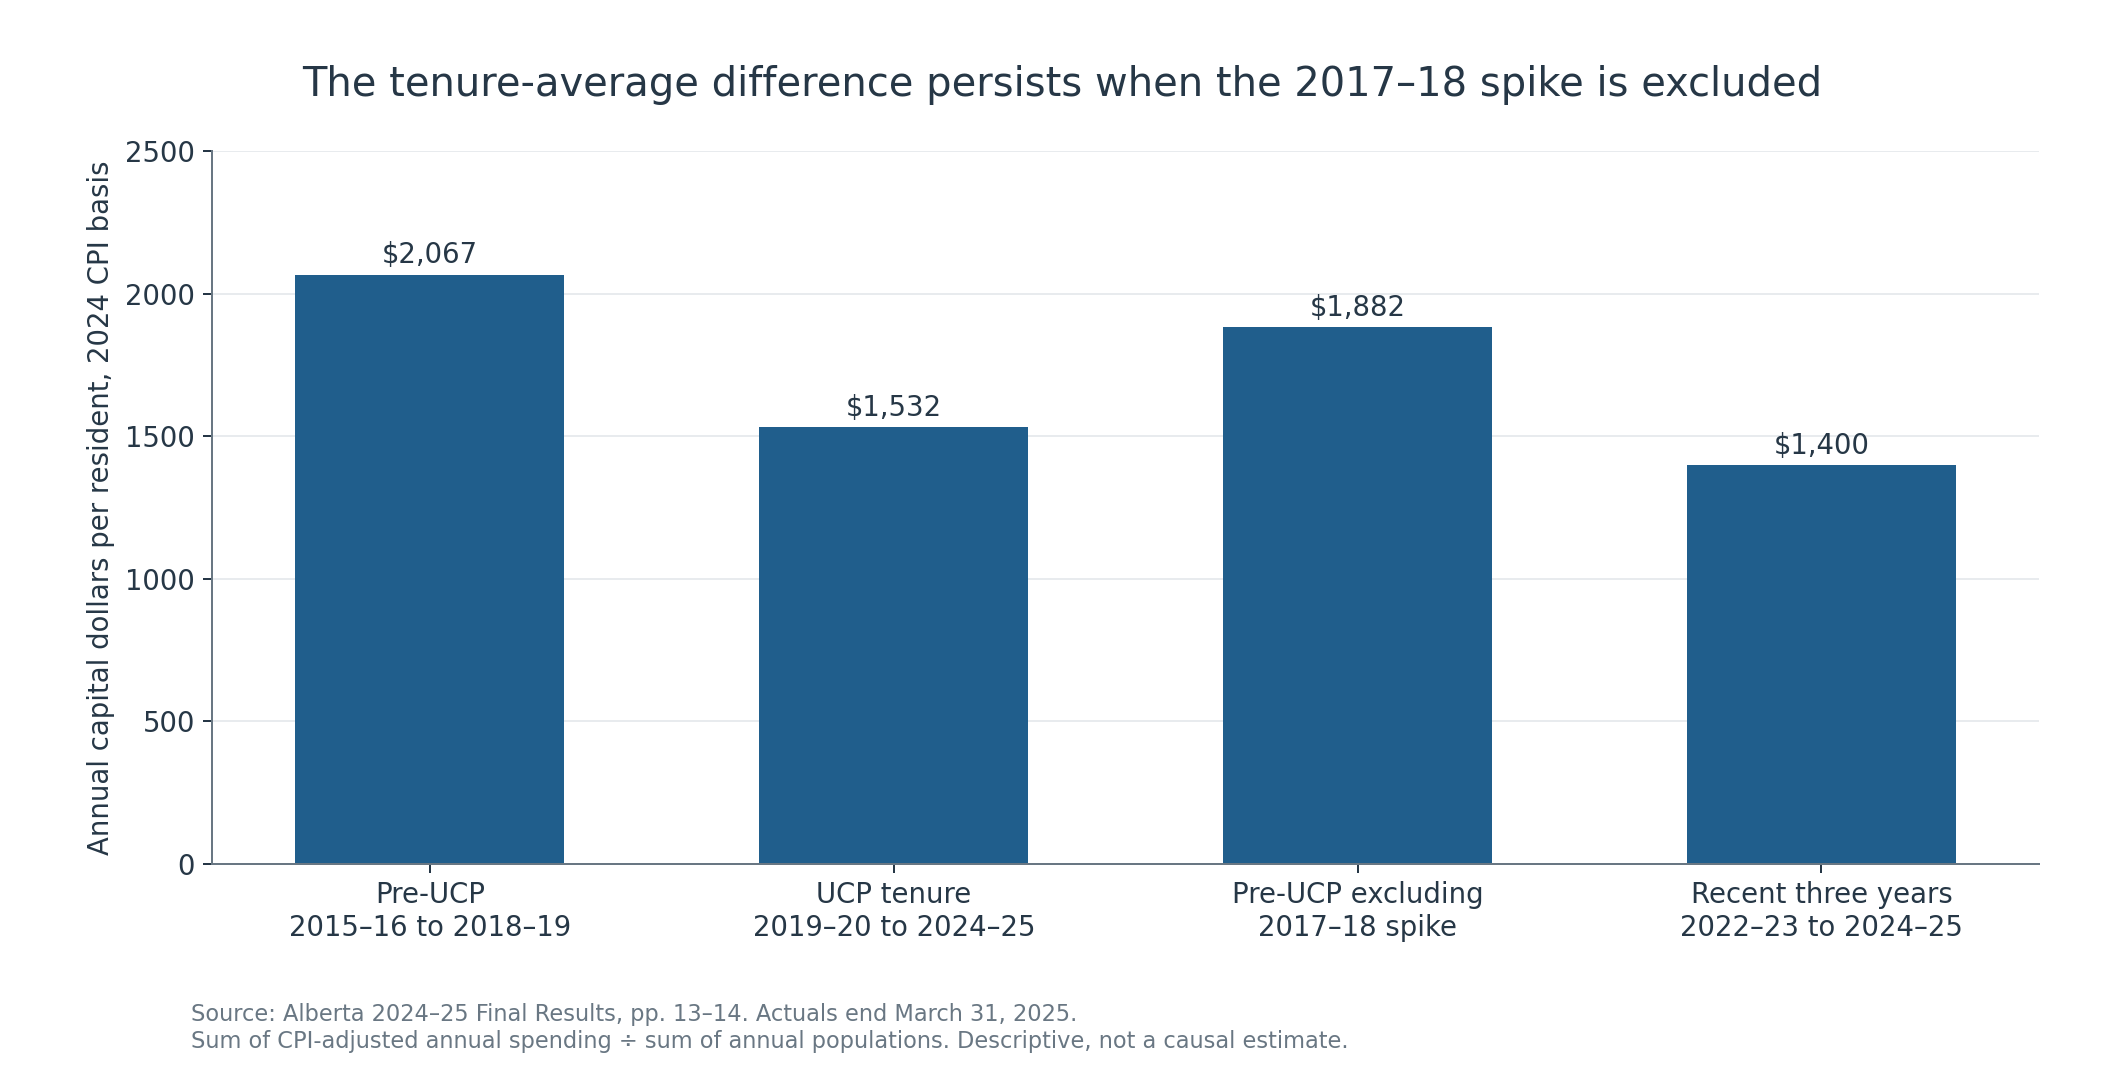

In [10]:
display(PERIODS[['period','fiscal_years','population_weighted_cpi_adjusted_per_resident_annual_2024_cad']].round(2))
display(Image(filename=str(ROOT/'plots/06_tenure_sensitivity.png'), alt='Weighted annual CPI-adjusted capital spending per resident is about 2067 dollars pre-UCP, 1532 dollars during UCP tenure, and 1882 dollars pre-UCP excluding the 2017–18 spike. These comparisons are descriptive, not causal.'))

### 6. Latest sector changes

Source p. 17 supplies 2023–24 actuals reclassified into the 2024–25 structure. Maintenance and self-financed spending are separate, so named sector envelopes are not all-in sector totals. These changes measure financial allocations, not net service delivery.

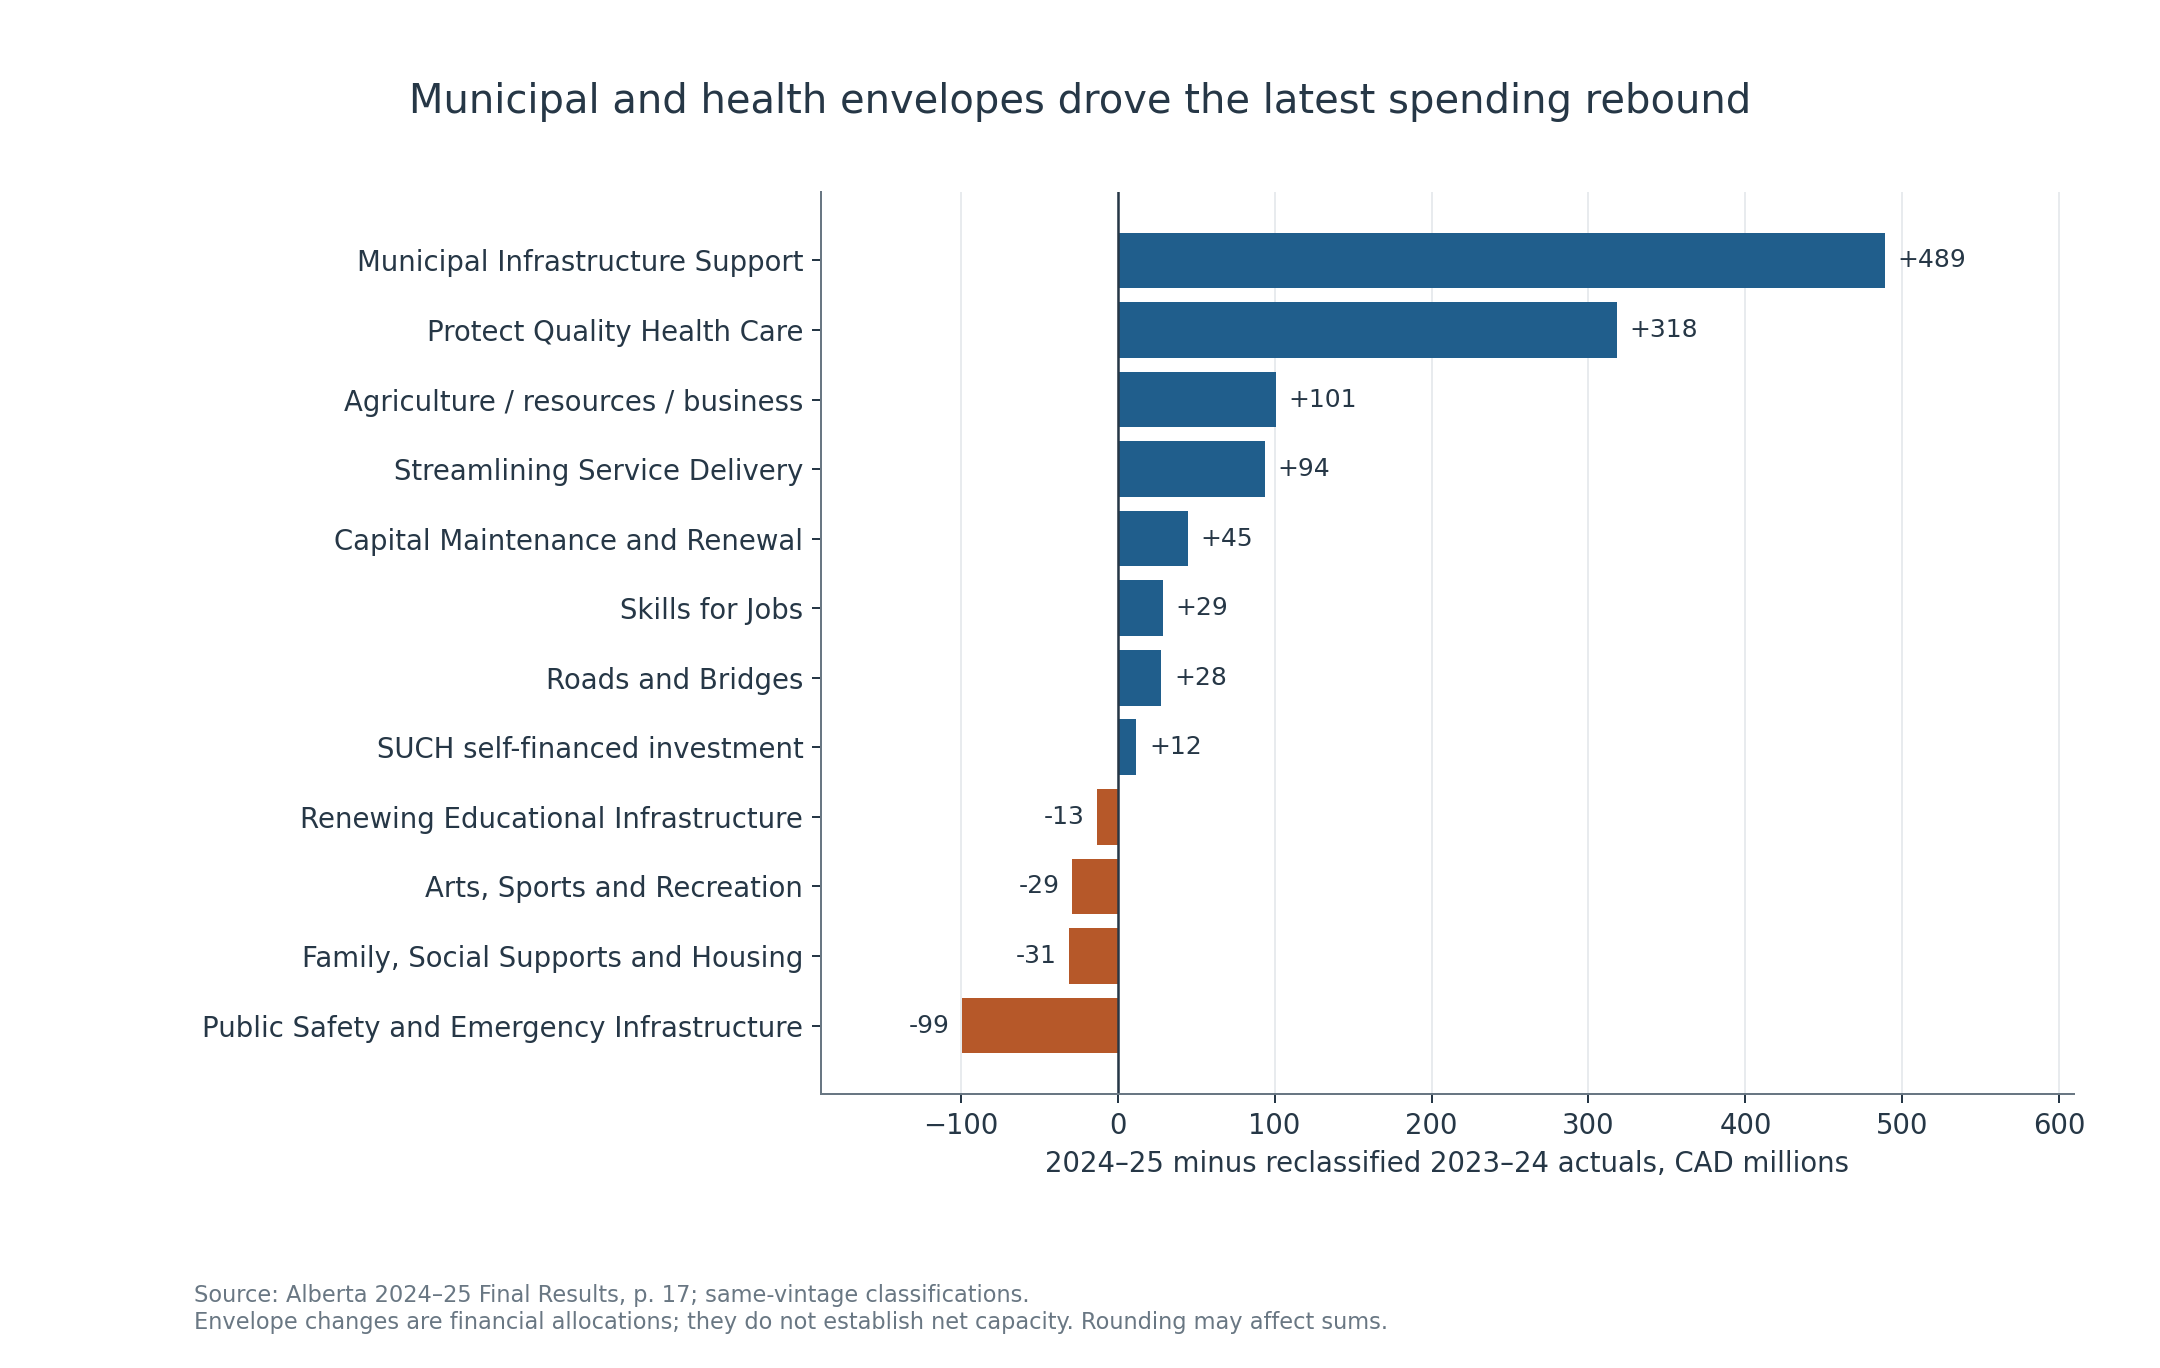

In [11]:
display(Image(filename=str(ROOT/'plots/05_latest_sector_changes.png'), alt='Latest actual capital-envelope changes. Municipal infrastructure rises 489 million dollars and health rises 318 million; education falls 13 million and public safety falls 99 million. Components have a one-million rounding difference from the consolidated total.'))

### 7. Rounding sensitivity

Worst-case rounding bounds are deterministic, not confidence intervals. They do not cover accounting revisions, fiscal-calendar alignment or construction-price uncertainty. The small 2019 baseline decline is especially sensitive to those broader assumptions.

In [12]:
display(COMPARISONS[['baseline','cpi_adjusted_per_resident_growth_pct','rounding_sensitivity_real_per_resident_growth_low_pct','rounding_sensitivity_real_per_resident_growth_high_pct']].round(3))

,baseline,cpi_adjusted_per_resident_growth_pct,rounding_sensitivity_real_per_resident_growth_low_pct,rounding_sensitivity_real_per_resident_growth_high_pct
0,2015-16,-25.802,-26.153,-25.448
1,2018-19,-12.589,-12.875,-12.302
2,2019-20,-1.395,-1.671,-1.119
3,2022-23,11.613,11.464,11.763
4,2023-24,7.066,6.976,7.156


### Price-measure sensitivity

The curve varies a hypothetical price factor while holding actual spending and population fixed. It is not observed construction inflation. A 5.0% cumulative factor is the break-even threshold for 2018–19 to 2024–25; the observed CPI chain is shown separately.

Illustrative threshold 5.003013%; construction inflation not estimated.


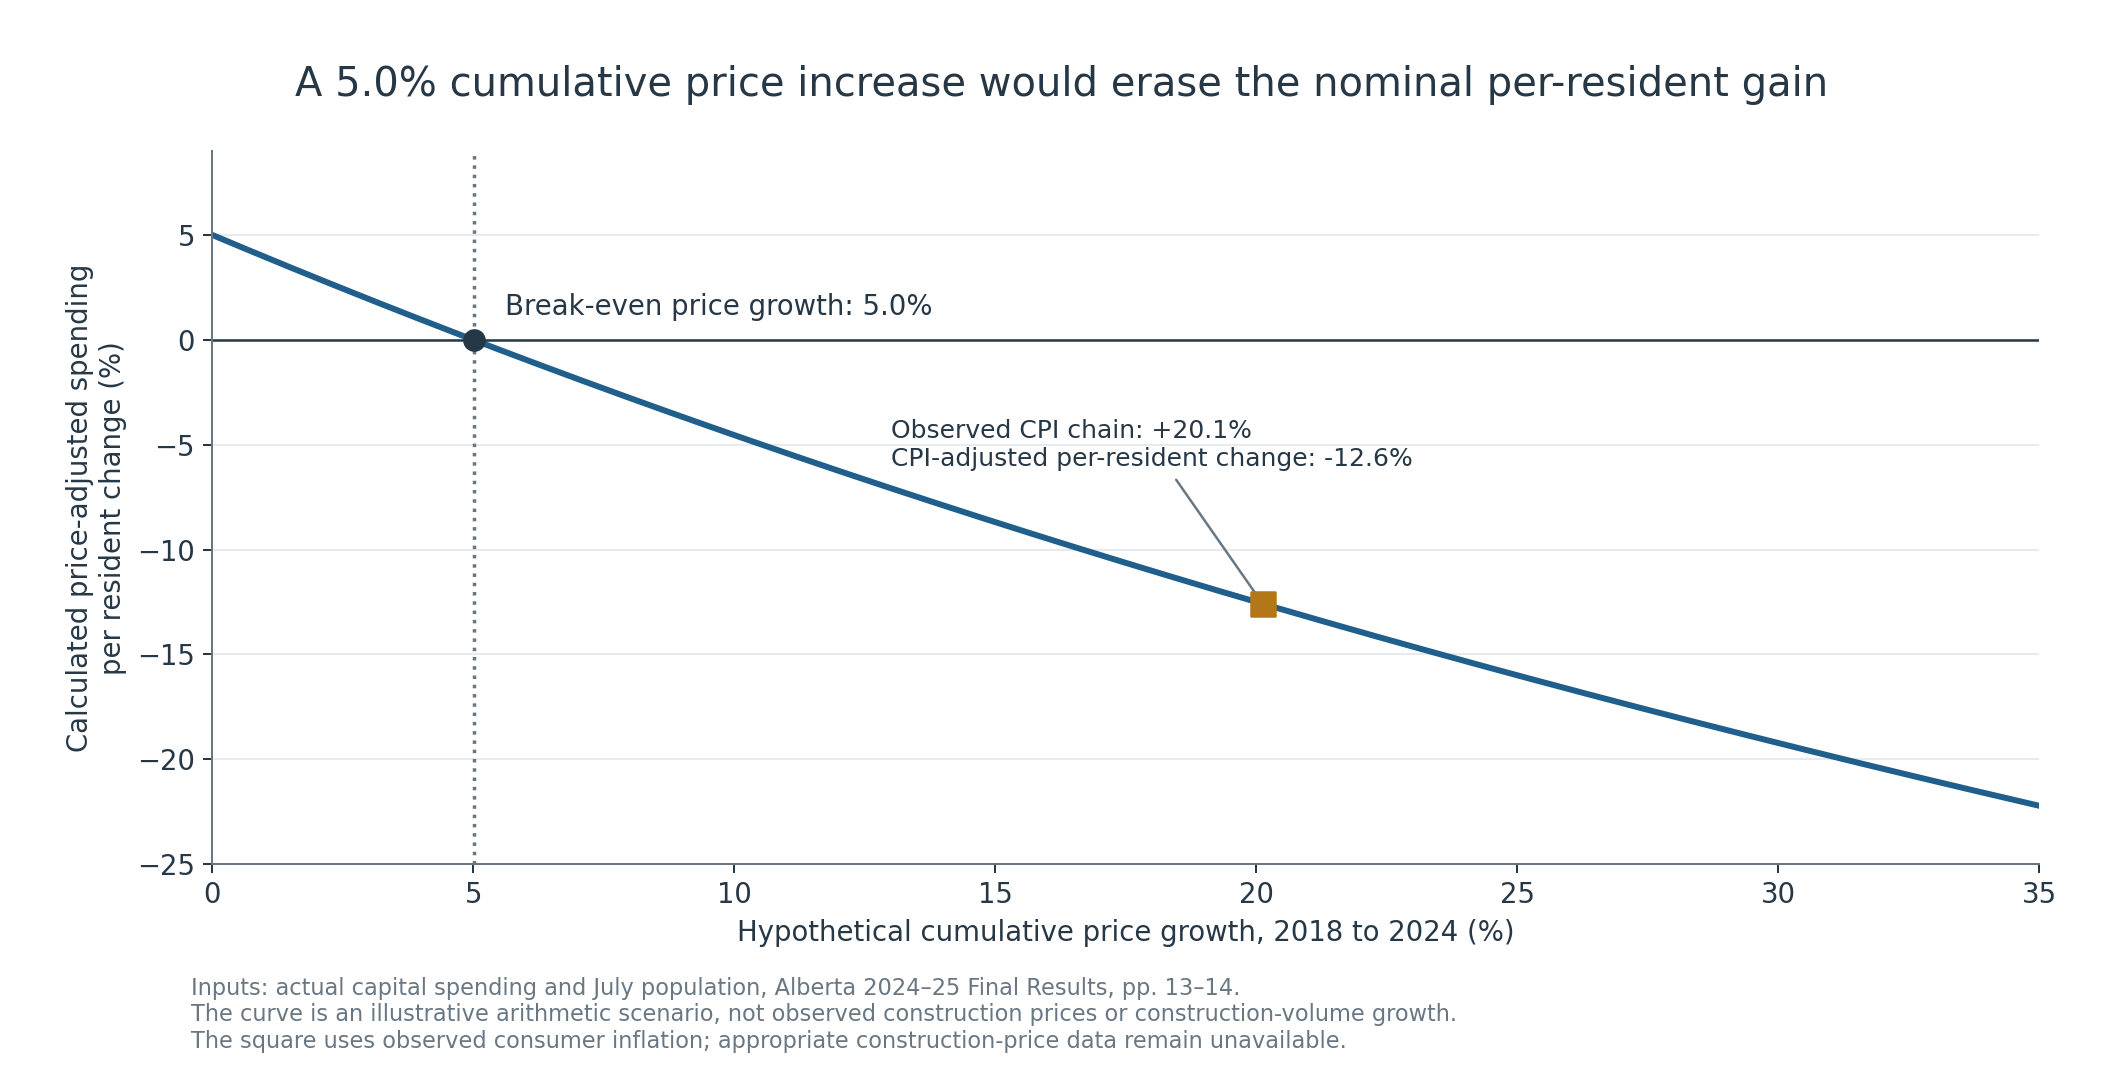

In [13]:
from price_sensitivity import build as build_price_sensitivity
build_price_sensitivity()
display(Image(filename=str(ROOT/'plots/08_hypothetical_price_sensitivity.png'), alt='Illustrative price sensitivity for 2018–19 to 2024–25. A hypothetical cumulative price increase of 5.0 percent is the per-resident break-even threshold. Observed consumer inflation of 20.1 percent produces a minus 12.6 percent adjusted change. Construction inflation is not observed.'))

### 8. Selected physical deliveries and missing net-capacity measures

The audited project ledger distinguishes inherited planning/construction, completed-status observations, explicitly dated construction completion and operational evidence. An as-of completed list need not record first completion in that year: Quest had operating evidence before its later listing. Unknown dates remain missing. See the full report for school-space definitions, mixed project counts, highway-unit conflicts and the health-count contradiction.

Earlier work for a phased program can concern its broader program, rather than initiation of the later named phase. The Calgary ring-road program and Grande Prairie hospital are shown with that scope.

Built selected physical-stage figure for 10 projects; no net-capacity inference.


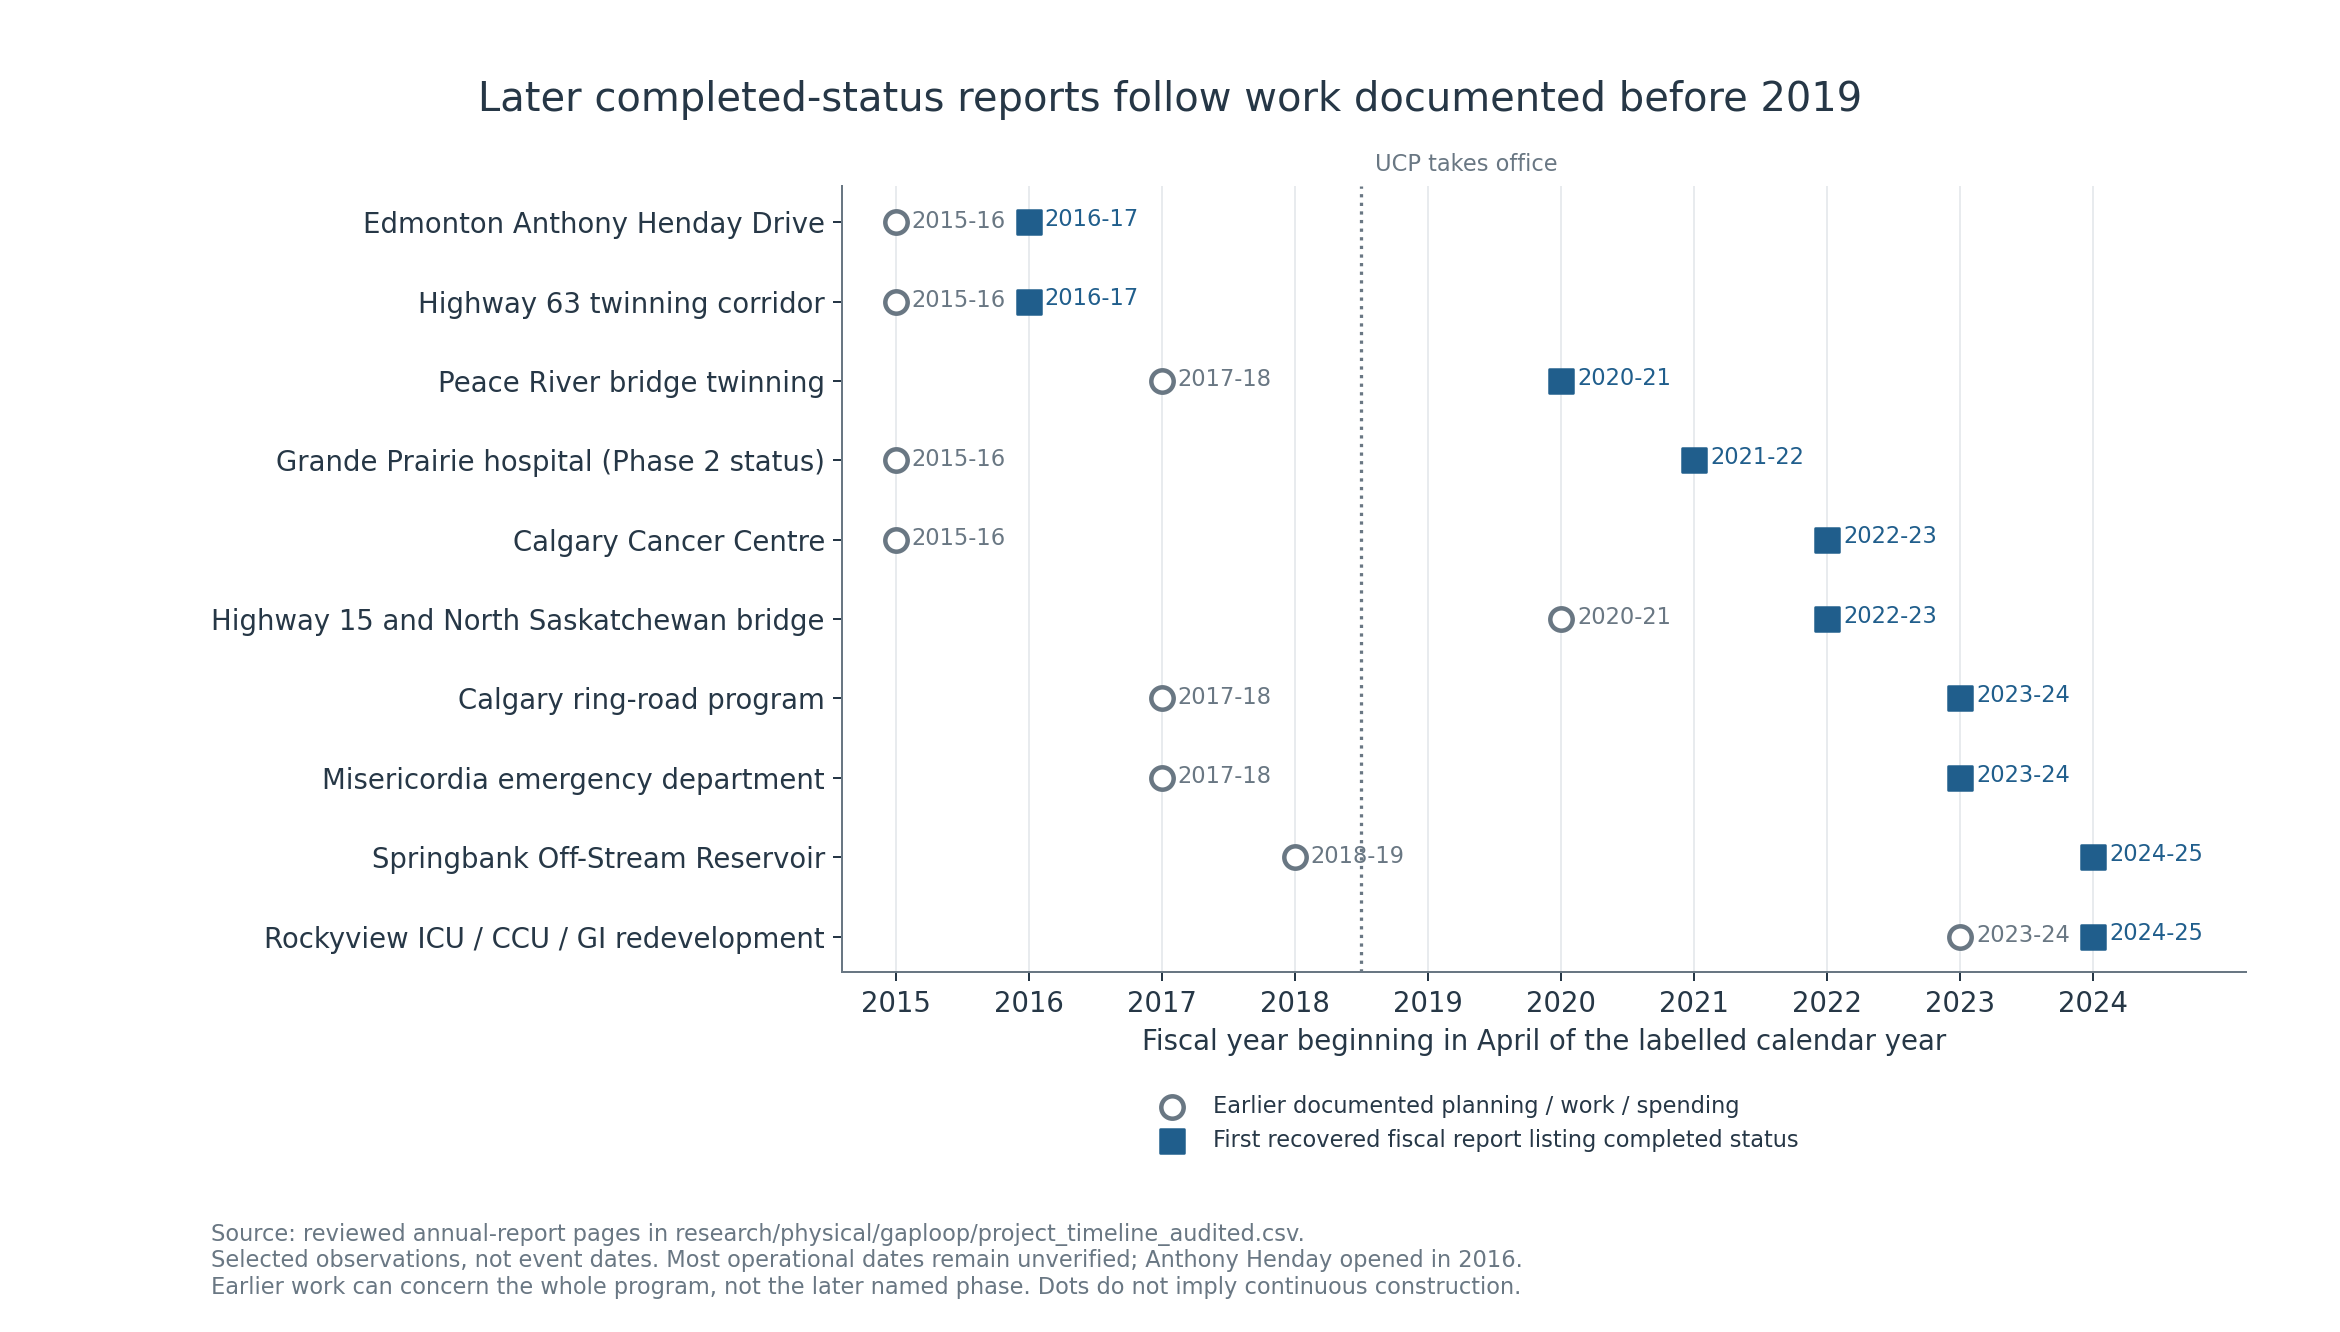

In [14]:
from physical_figures import build as build_physical_figure
build_physical_figure()
display(Image(filename=str(ROOT/'plots/07_selected_project_stages.png'), alt='Selected project-stage observations show earlier work before 2019 and later listed completion for Grande Prairie hospital Phase 2, Calgary Cancer Centre, Misericordia emergency department, Peace River bridge, Calgary ring road and Springbank reservoir. Earlier observations are not initiation dates, and completion definitions differ.'))

In [15]:
timeline = pd.read_csv(ROOT/'research/physical/gaploop/project_timeline_audited.csv')
display(timeline[['project','sector','first_observed_earlier_stage_year','first_reported_completed_status_fy','explicit_construction_completion_fy','operational_year_if_verified']].head(17))

,project,sector,first_observed_earlier_stage_year,first_reported_completed_status_fy,explicit_construction_completion_fy,operational_year_if_verified
0,Grande Prairie Regional Hospital Phase 2 (join...,health,2015-16,2021-22,NaN,NaN
1,Calgary Cancer Centre,health,2015-16,2022-23,NaN,NaN
2,Misericordia Community Hospital emergency depa...,health,2017-18,2023-24,NaN,NaN
3,Lakeview Recovery Community Gunn,health,NaN,2023-24,NaN,NaN
4,Rockyview General Hospital ICU CCU GI redevelo...,health,2023-24,2024-25,NaN,NaN
5,Chinook Regional Hospital Lethbridge surgical ...,health,NaN,2024-25,NaN,NaN
6,High Prairie Health Complex renal dialysis,health,NaN,2021-22,NaN,NaN
7,Edmonton Anthony Henday Drive ring road,roads,2015-16,2016-17,2016-17,2016.0
8,Highway63 twinning Grassland to Fort McMurray,roads,2015-16,2016-17,2016-17,NaN
9,Calgary ring road whole program (final western...,roads,2017-18,2023-24,NaN,NaN


## Takeaways

1. Alberta spent more nominal capital dollars in 2024–25 than in 2018–19, but less per resident after the CPI adjustment.
2. The latest rebound and the lower 2019 baseline matter; show both rather than selecting a single partisan comparison.
3. Documented schools, health projects, roads, bridges and flood protection demonstrate physical deliveries across administrations.
4. Consistent net capacity, operational readiness and condition data remain needed to establish adequacy relative to population. No spending ratio settles that question.

Reproduce using README.md. Independently recomputed calculations and correction history are retained in review/.